In [1]:
#venv_fswot
# (need cftime)

#%matplotlib inline
import numpy as np
from datetime import timedelta, datetime

In [2]:
from glob import glob
import xarray as xr
import matplotlib.pyplot as plt
from netCDF4 import num2date, date2num


import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib import colors 

import cartopy
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
#from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter#
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec

In [3]:
rootdir = "/Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/"

# Drifters:

In [7]:
filedir = "./../../../../../../data/drifters/L1_IMEDEA/"

# outname = url_drifter.split('/')[-1][0:-1].replace('L0', 'L1').replace('scb', 'ime') #outname
# --> substitute L0 by L1 and scb by ime. [0:-1], because last character in string is ?
# outname = outname.split('_')[1]

ndrifters = np.arange(1, 21) #
ndrifters = np.delete(ndrifters, [3, 9, 11, 12, 18]) # --> removing short trajs
print(ndrifters)

[ 1  2  3  5  6  7  8  9 11 14 15 16 17 18 20]


In [8]:
outdir_root = '/Users/Gomez023/Library/CloudStorage/OneDrive-UniversitatdelesIllesBalears/FaSt-SWOT/'
# outdir_root + 'Figures/Drifters/IOs/CU_filt/'
outdir = outdir_root + 'Data/in_situ/analyses/drifters/CARTHE/'


1


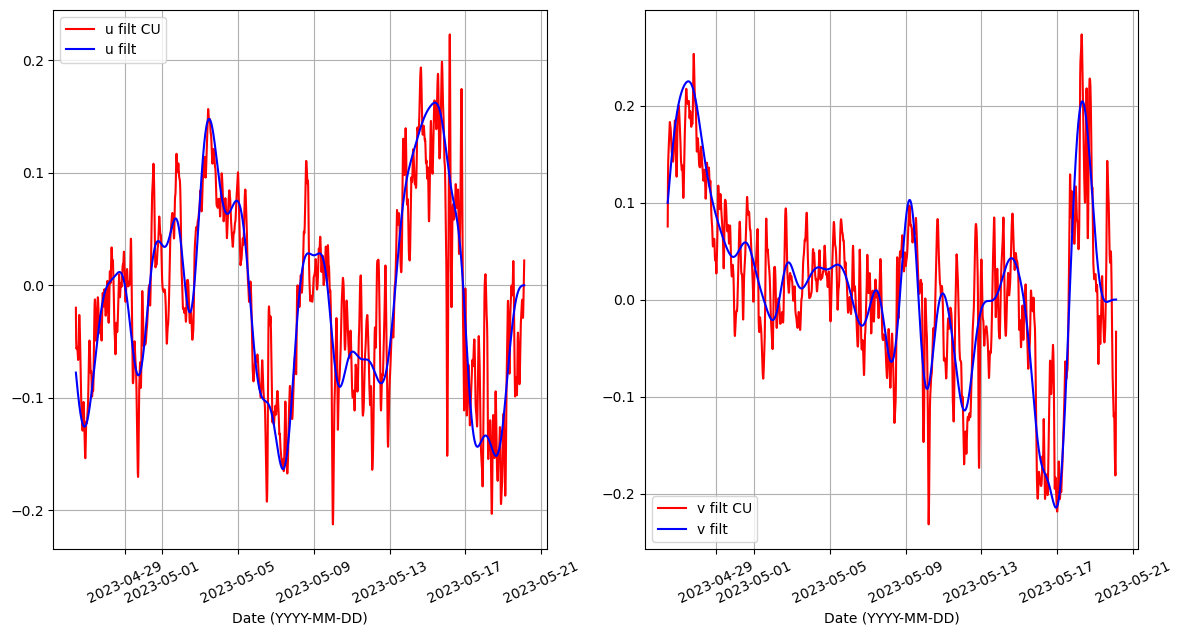

2


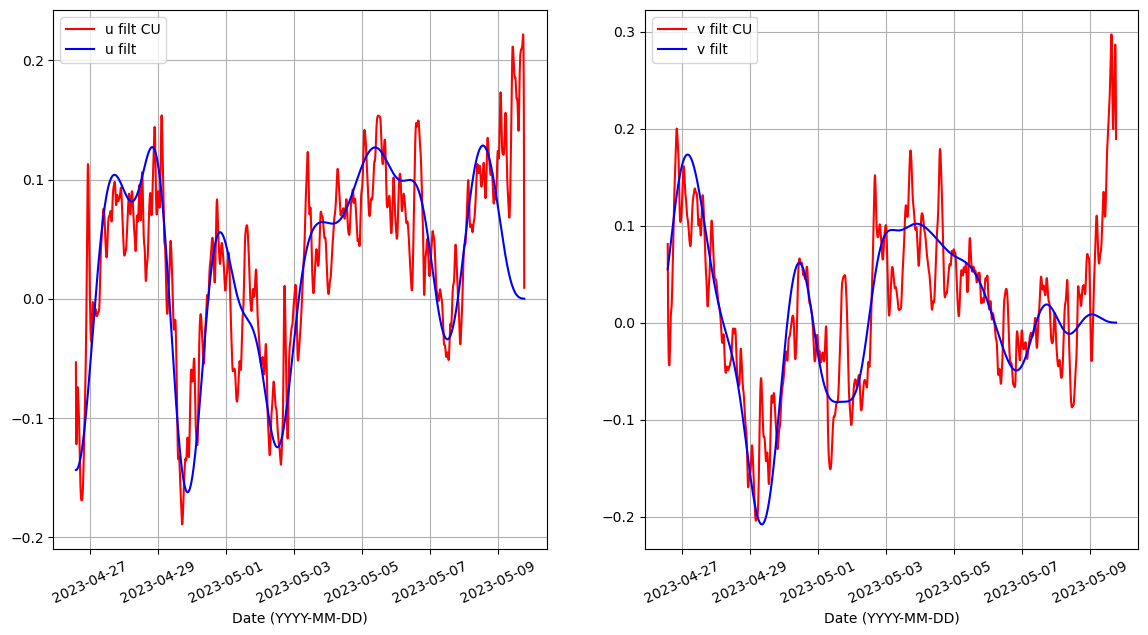

3


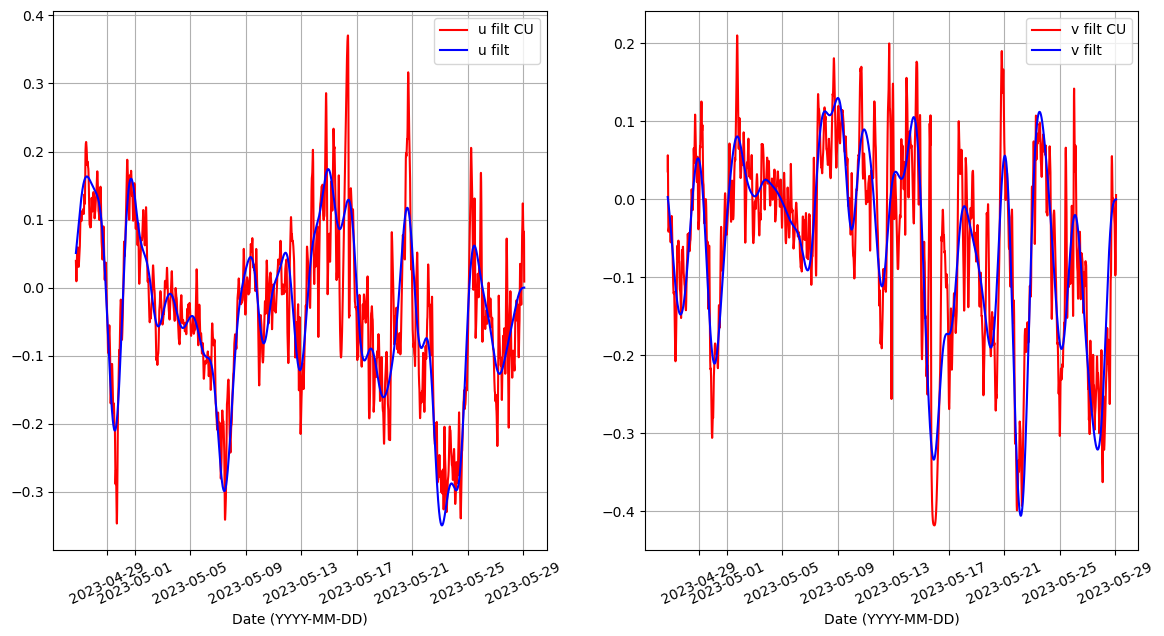

5


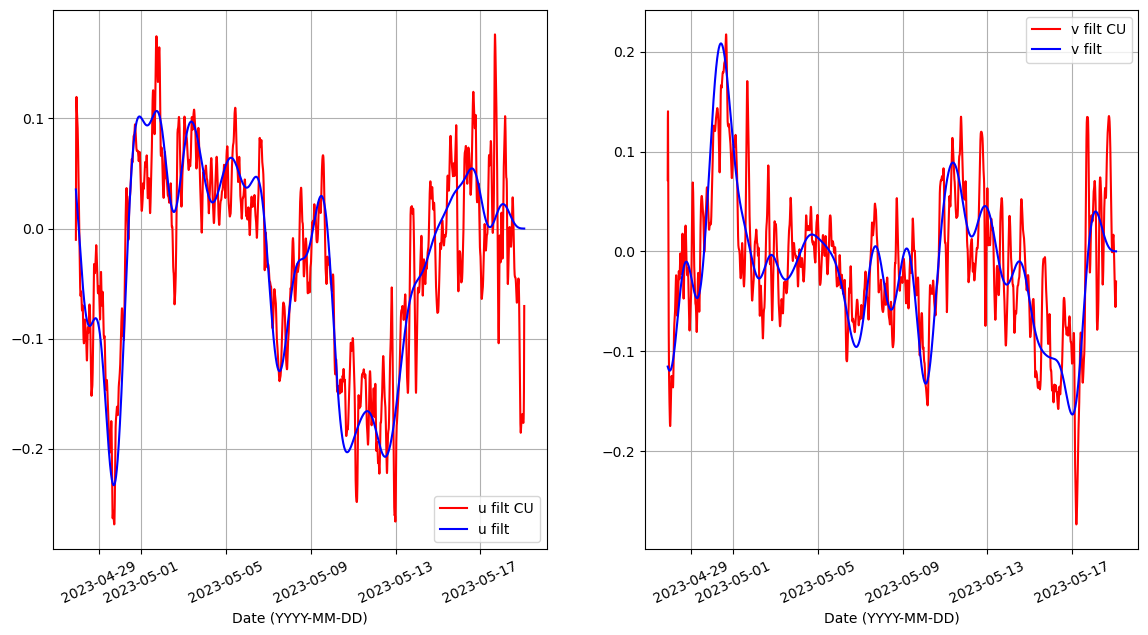

6


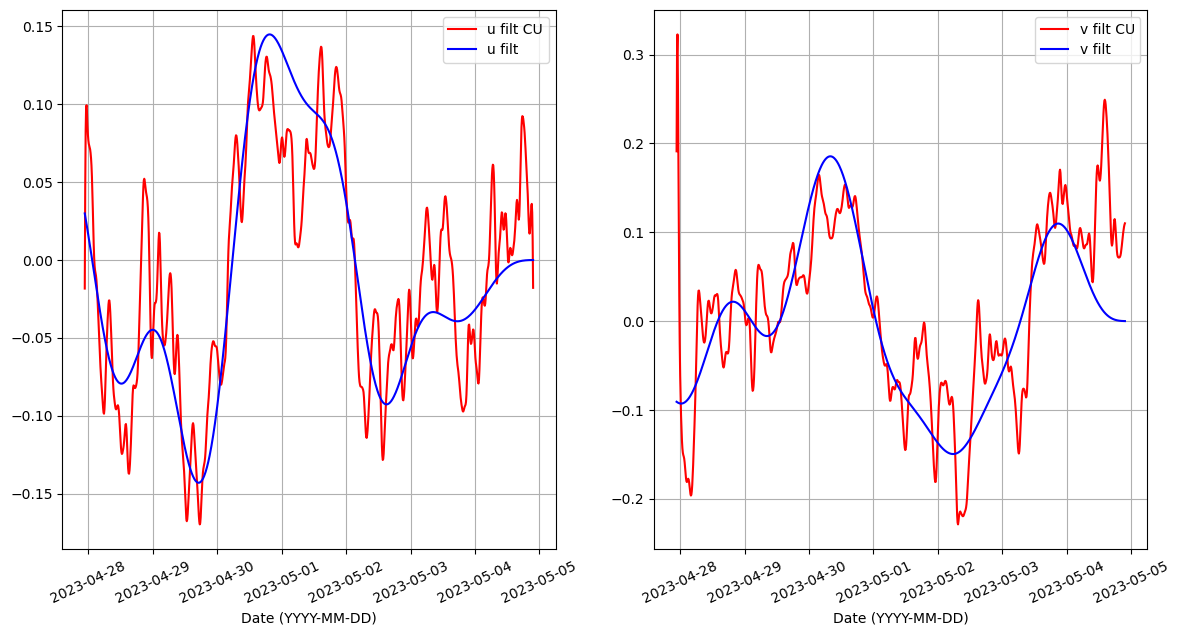

7


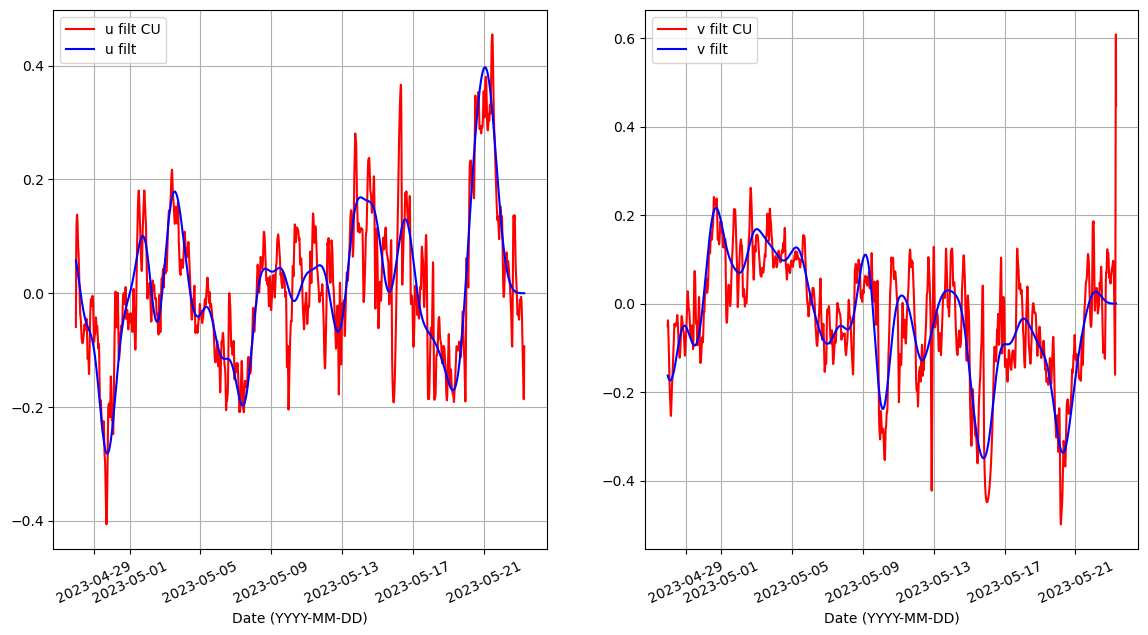

8


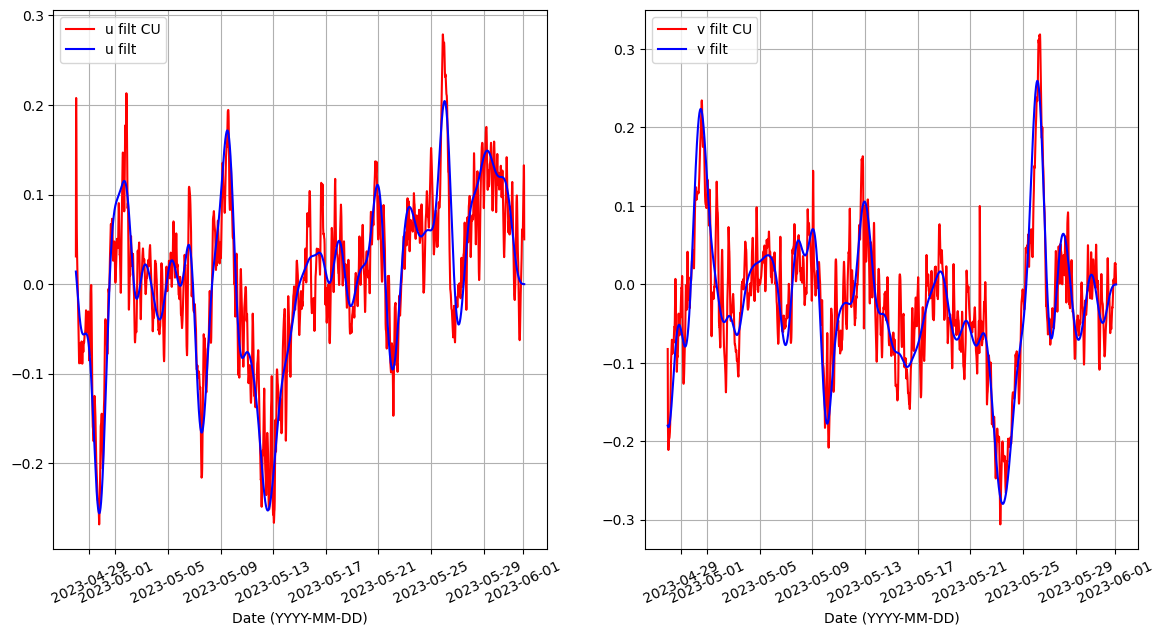

9


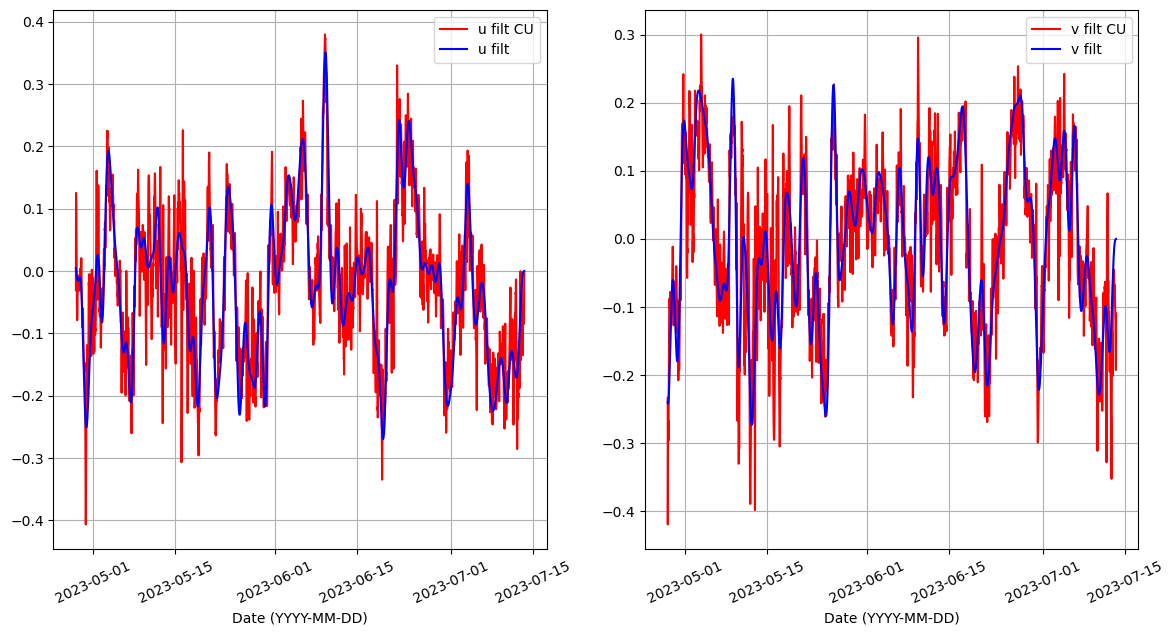

11


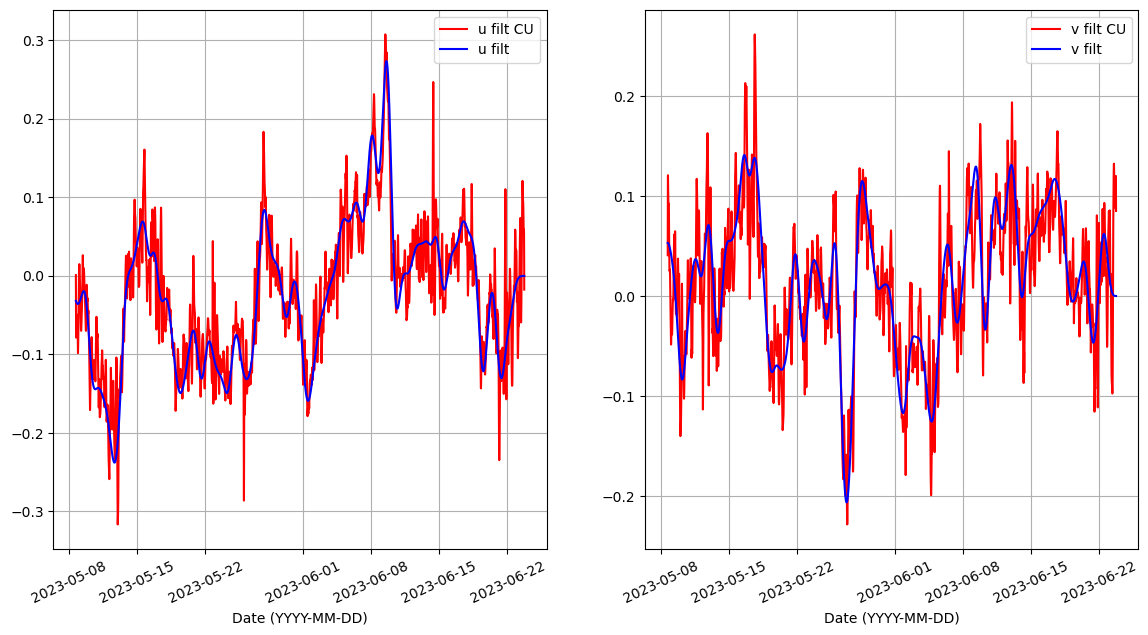

14


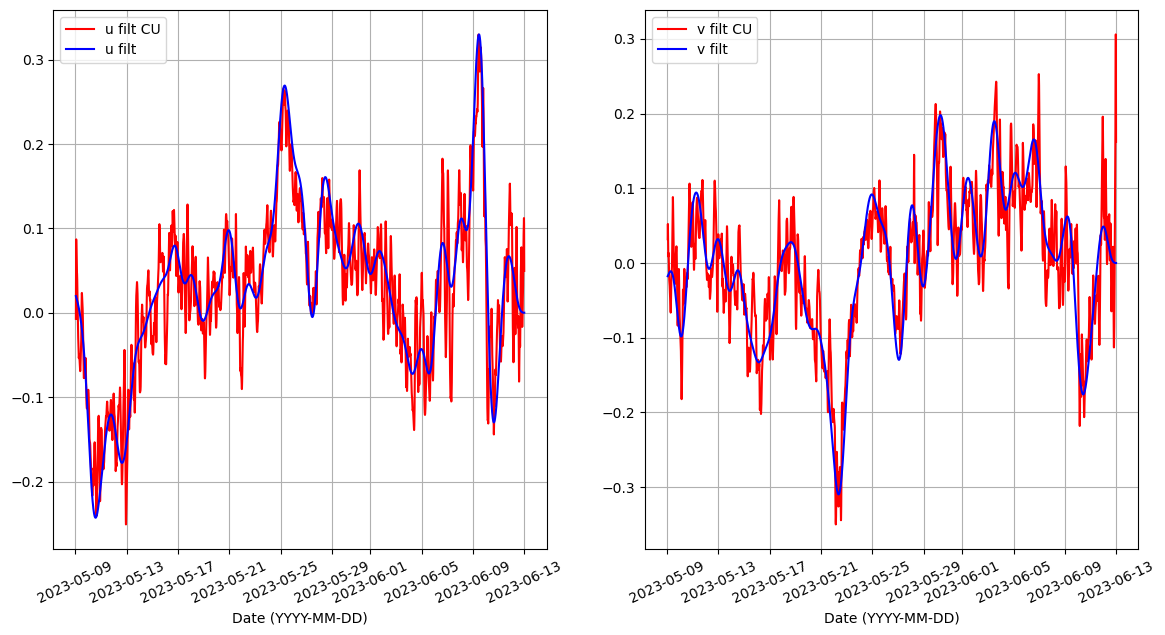

15


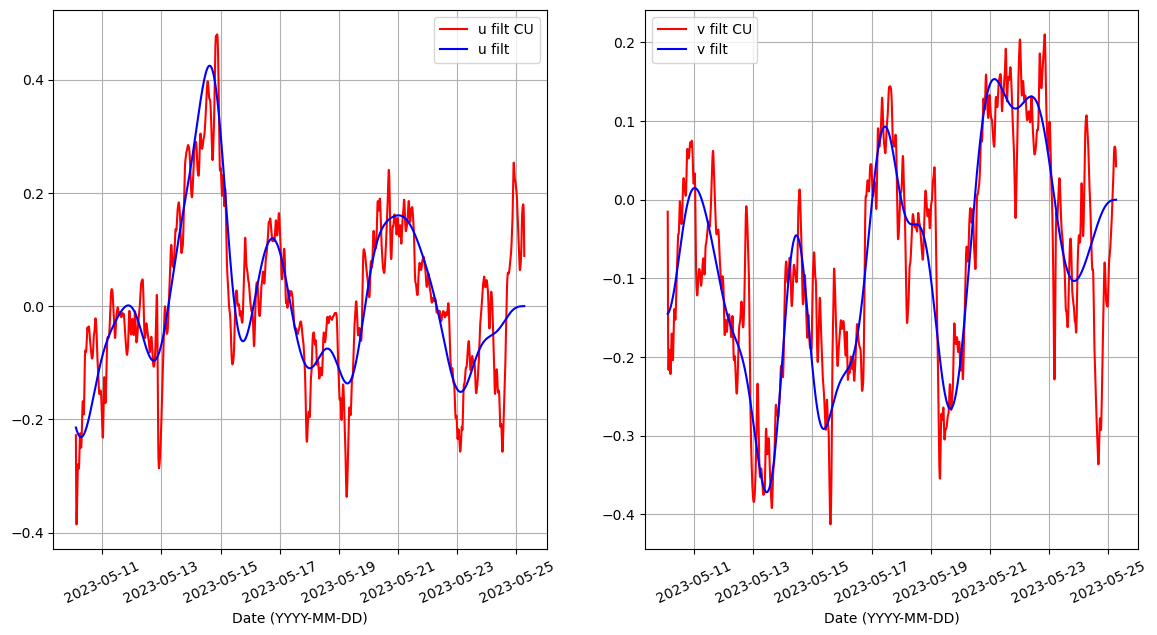

16


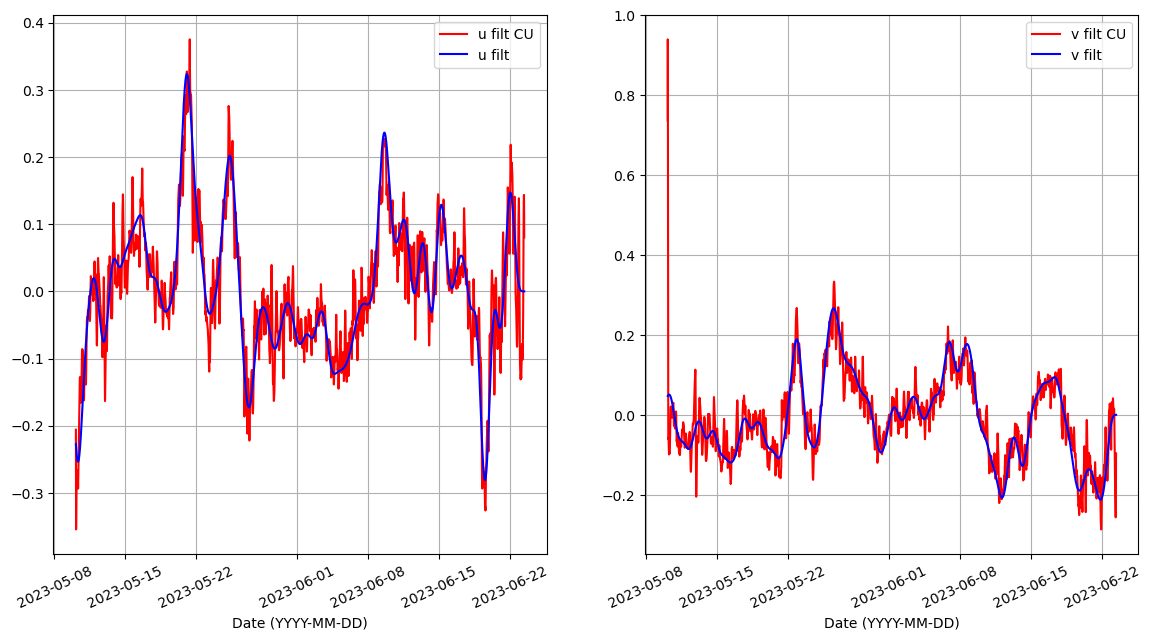

17


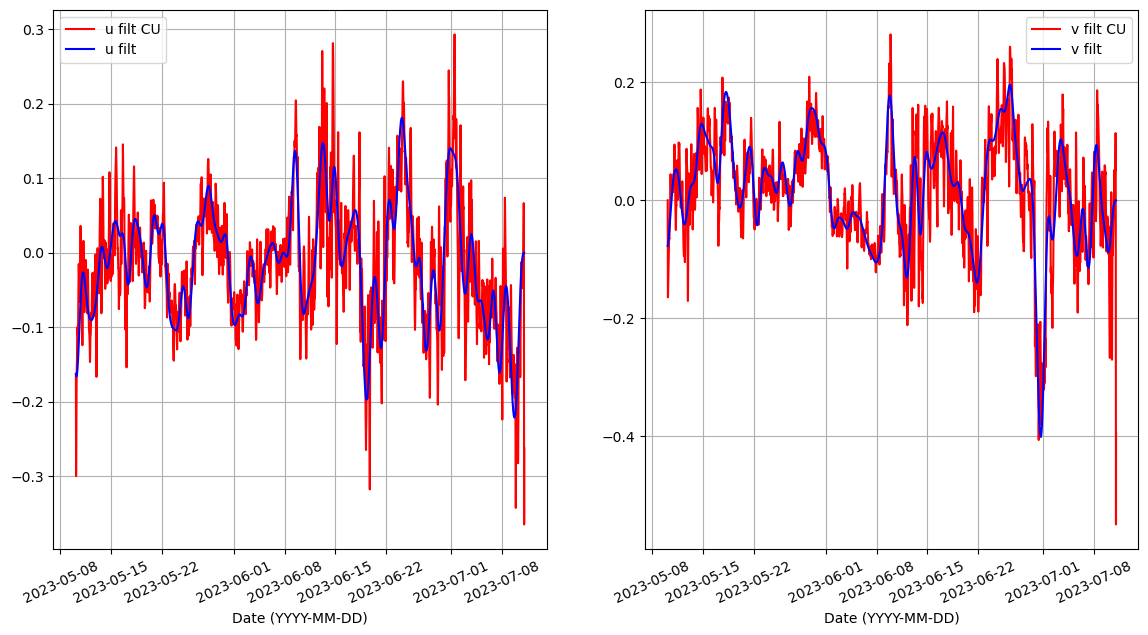

18


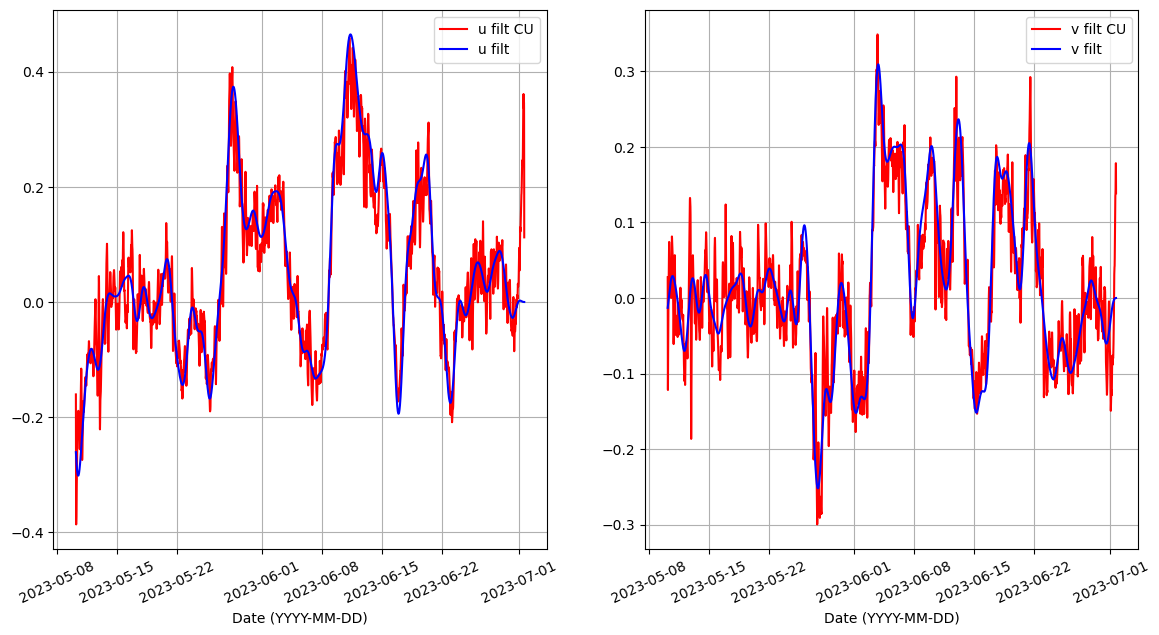

20


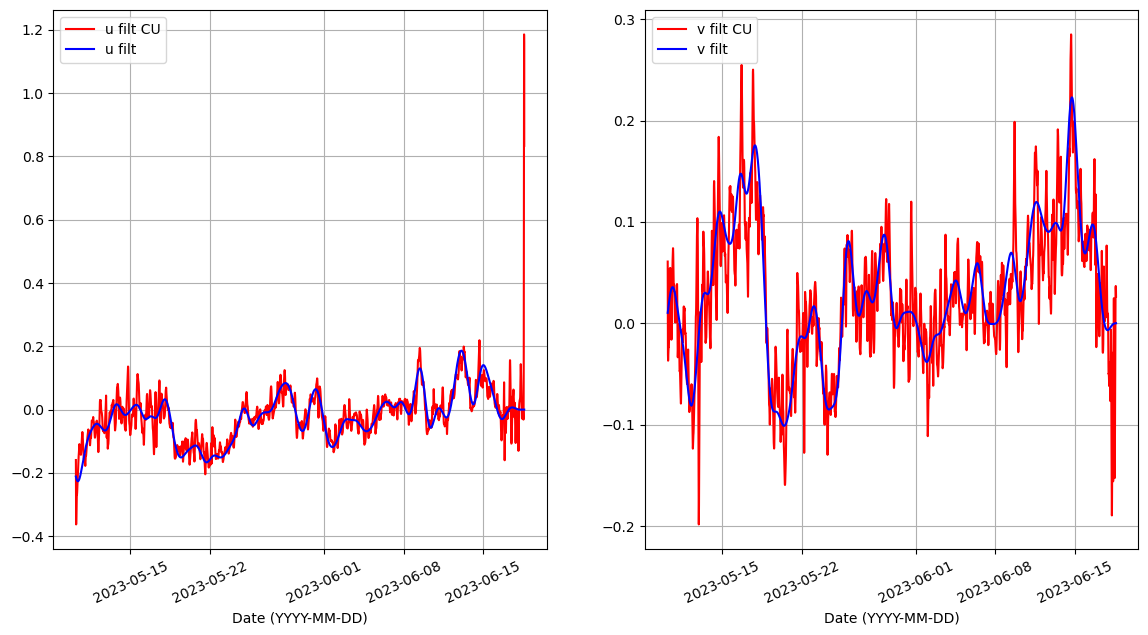

In [9]:
for ndrifter in ndrifters:
    print(ndrifter)
    drifter_num = str(ndrifter).zfill(3)
    drifter_num2 = str(ndrifter + 5).zfill(3)
    
    inname = 'drifter-carthe' + drifter_num 

    # Filt. Butterworth
    outname01 = outdir + inname + '_inertial_osc_filt_v2.nc' 
    ds01 = xr.open_dataset(outname01)
    
    # Filt CU
    outname = inname + '_inertial_osc_filt_CU.nc'
    ds_02 = xr.open_dataset(outdir + outname)
 
    # Plot:
    fig = plt.figure(figsize=(14,7))
    plt.subplot(121)
    plt.plot(ds_02.time, ds_02.U_filt, c='r', label='u filt CU')
    plt.plot(ds01.time, ds01.U, c='b', label='u filt')
    plt.xticks(rotation=25)
    plt.xlabel('Date (YYYY-MM-DD)')
    plt.legend()
    plt.grid()
    plt.subplot(122)
    plt.plot(ds_02.time, ds_02.V_filt, c='r', label='v filt CU')
    plt.plot(ds01.time, ds01.V, c='b', label='v filt')
    plt.legend()
    plt.grid()
    plt.xticks(rotation=25)
    plt.xlabel('Date (YYYY-MM-DD)')
    plt.show()

# Old version:

In [ ]:
ndrifters = np.arange(1, 7) #21
ndrifters = np.delete(ndrifters, [3]) #, 9, 11, 12, 18]) # --> removing short trajs
print(ndrifters)

1


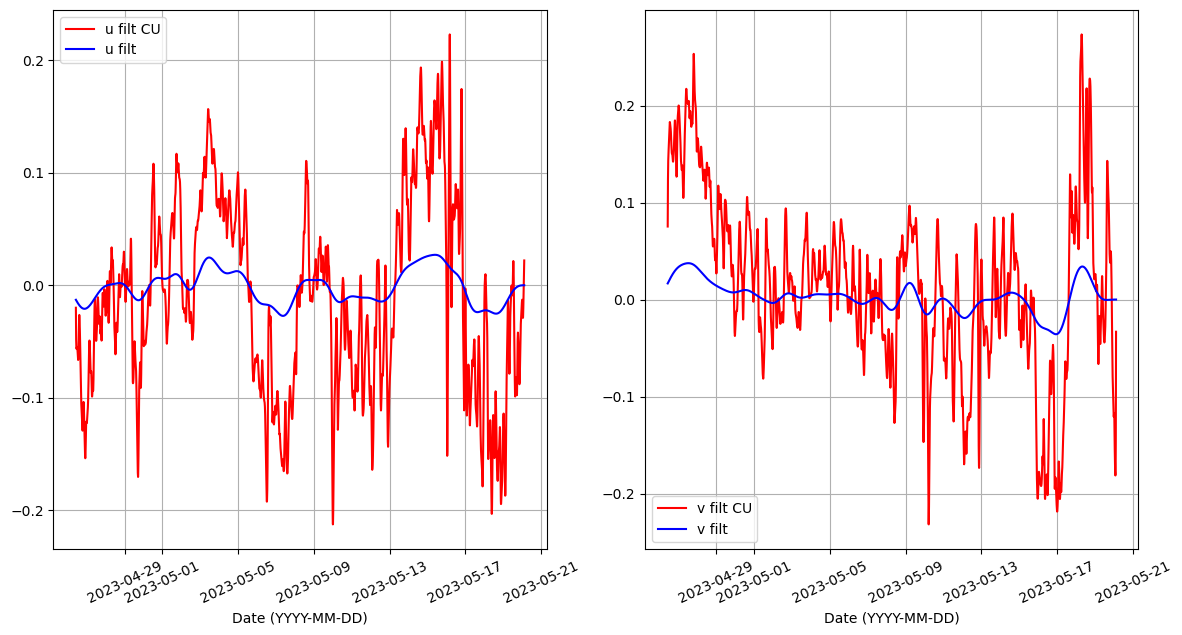

2


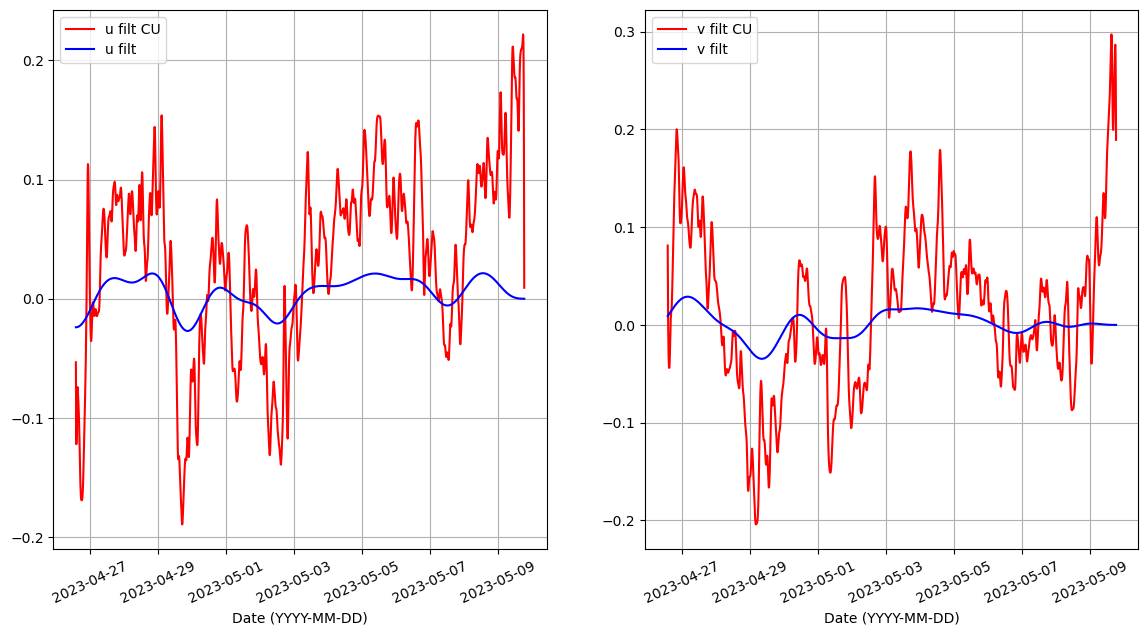

3


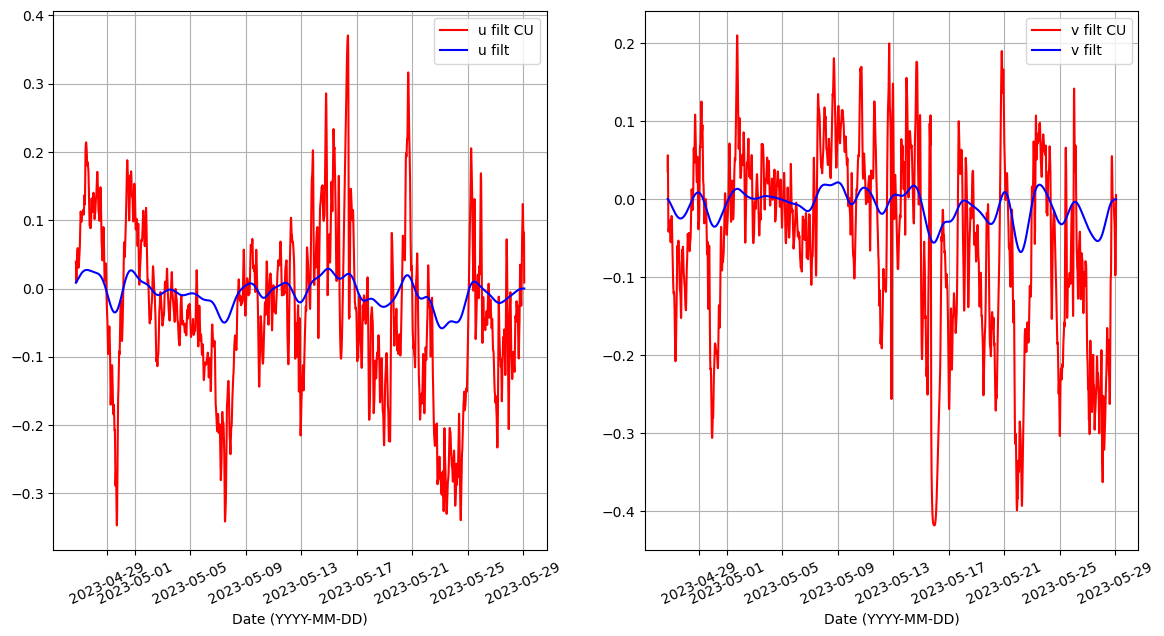

5


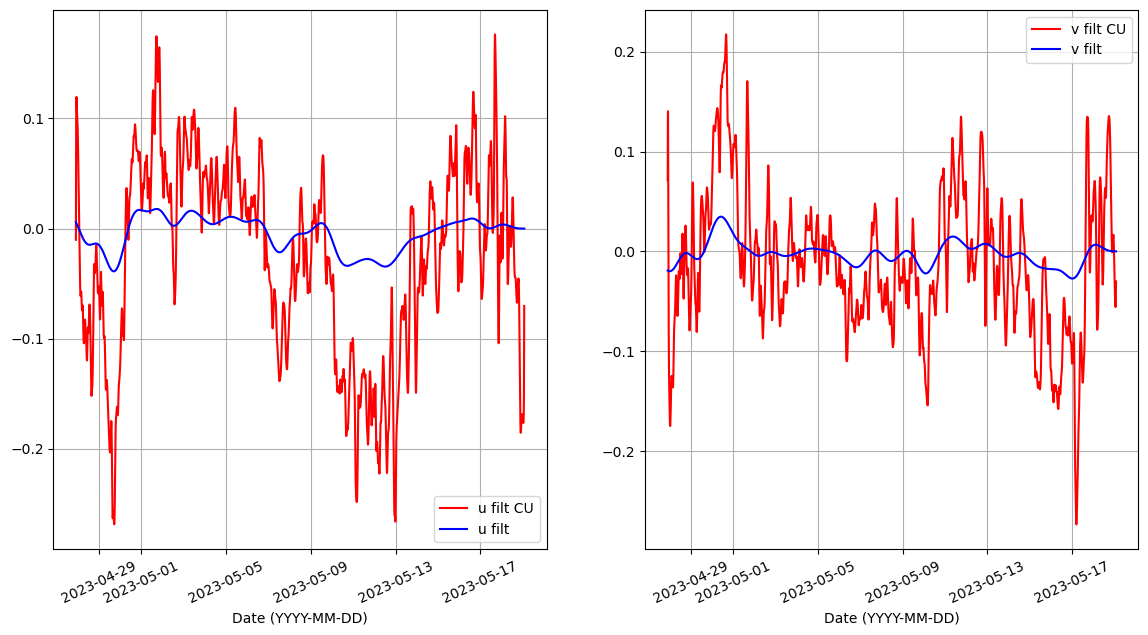

6


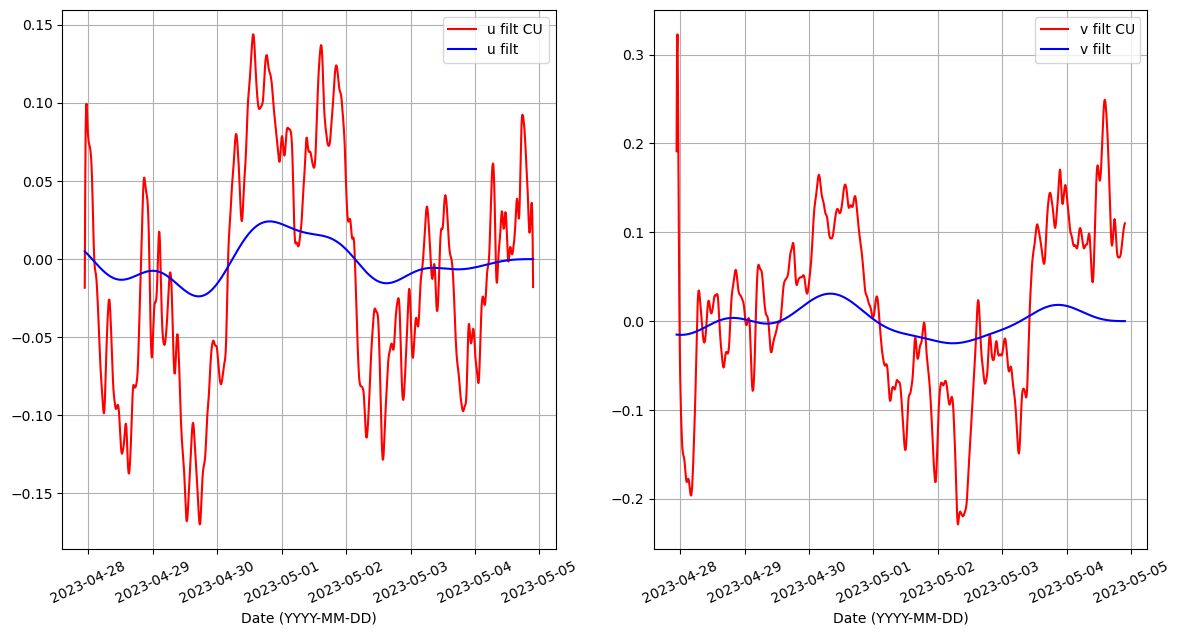

In [12]:
for ndrifter in ndrifters:
    print(ndrifter)
    drifter_num = str(ndrifter).zfill(3)
    drifter_num2 = str(ndrifter + 5).zfill(3)
    
    # Filt
    inname01 = 'drifter_carthe' + drifter_num2 + '-ime_carthe' + drifter_num
    outname01 = outdir + inname01 + '_inertial_osc_filt.nc' 
    ds01 = xr.open_dataset(outname01)
    
    # Filt CU
    inname02 = 'drifter-carthe' + drifter_num 
    outname = inname02 + '_inertial_osc_filt_CU.nc'
    ds_02 = xr.open_dataset(outdir + outname)
 
    # Plot:
    fig = plt.figure(figsize=(14,7))
    plt.subplot(121)
    plt.plot(ds_02.time, ds_02.U_filt, c='r', label='u filt CU')
    plt.plot(ds01.time, ds01.U, c='b', label='u filt')
    plt.xticks(rotation=25)
    plt.xlabel('Date (YYYY-MM-DD)')
    plt.legend()
    plt.grid()
    plt.subplot(122)
    plt.plot(ds_02.time, ds_02.V_filt, c='r', label='v filt CU')
    plt.plot(ds01.time, ds01.V, c='b', label='v filt')
    plt.legend()
    plt.grid()
    plt.xticks(rotation=25)
    plt.xlabel('Date (YYYY-MM-DD)')
    plt.show()

# --> like hereon, carthe seem to be oversmoothed with cut-off filter!